In [4]:
import pandas as pd

df = pd.read_excel("../datasets/onedata.xlsx")

- **We use one HOT ENCODER when data is not ordinal**
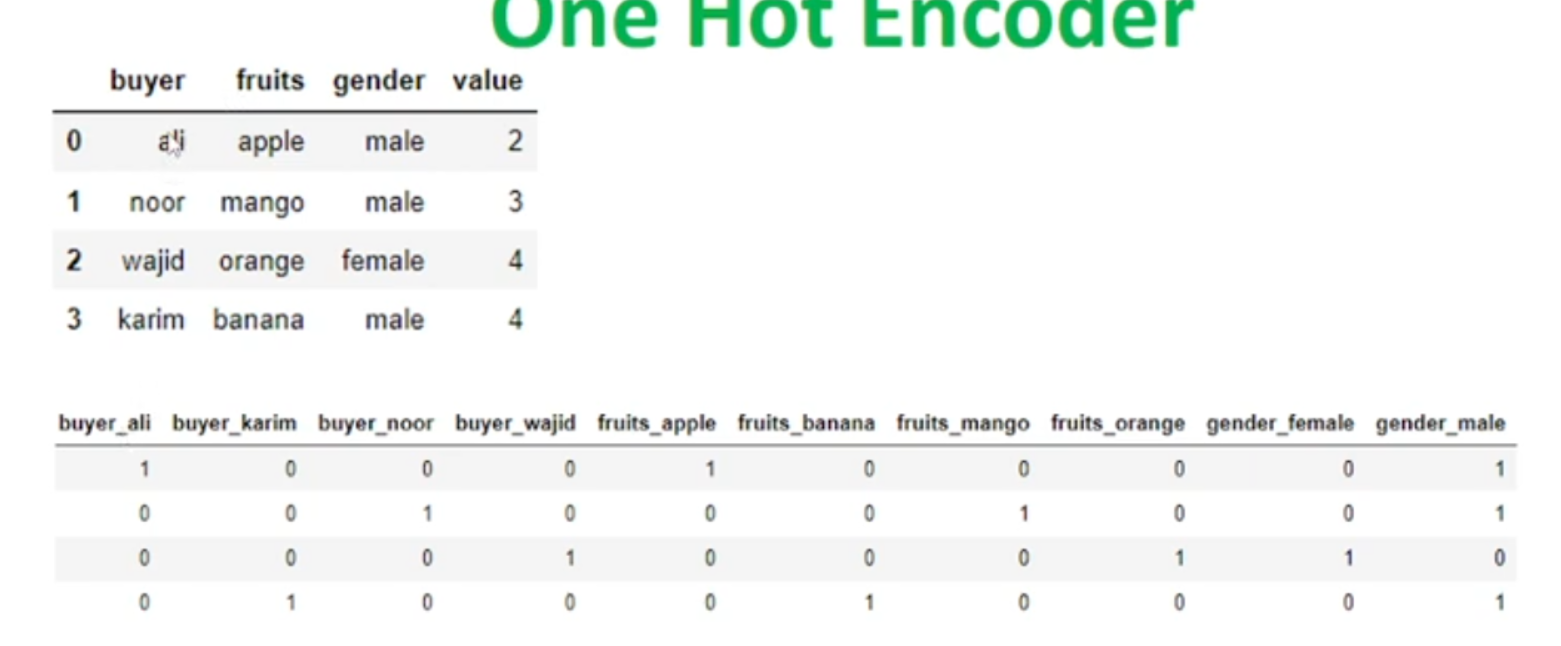

In [5]:
df

,buyer,fruits,gender,value
0,ali,apple,male,2
1,noor,mango,male,3
2,wajid,orange,female,4
3,karim,banana,male,4


- **Using Pandas**

In [7]:
pd.get_dummies(data = df, columns = ['buyer', 'fruits', 'gender'])

,value,buyer_ali,buyer_karim,buyer_noor,buyer_wajid,fruits_apple,fruits_banana,fruits_mango,fruits_orange,gender_female,gender_male
0,2,True,False,False,False,True,False,False,False,False,True
1,3,False,False,True,False,False,False,True,False,False,True
2,4,False,False,False,True,False,False,False,True,True,False
3,4,False,True,False,False,False,True,False,False,False,True


In [8]:
pd.get_dummies(data = df, columns = ['buyer', 'fruits', 'gender'], dtype=int)

,value,buyer_ali,buyer_karim,buyer_noor,buyer_wajid,fruits_apple,fruits_banana,fruits_mango,fruits_orange,gender_female,gender_male
0,2,1,0,0,0,1,0,0,0,0,1
1,3,0,0,1,0,0,0,1,0,0,1
2,4,0,0,0,1,0,0,0,1,1,0
3,4,0,1,0,0,0,1,0,0,0,1


- **Removing categories to make data set dimensions accurate**

In [9]:
pd.get_dummies(data = df, columns =['buyer', 'fruits', 'gender'], dtype=int, drop_first='first')

,value,buyer_karim,buyer_noor,buyer_wajid,fruits_banana,fruits_mango,fruits_orange,gender_male
0,2,0,0,0,0,0,0,1
1,3,0,1,0,0,1,0,1
2,4,0,0,1,0,0,1,0
3,4,1,0,0,1,0,0,1


# **Using SKLEARN ONE HOT ENCODER**

In [15]:
from sklearn.preprocessing import OneHotEncoder

In [21]:
ohe = OneHotEncoder(drop='first', dtype=int, sparse_output=False)

In [23]:
df_trf =ohe.fit_transform(df[['buyer', 'fruits', 'gender']])
df_trf

array([[0, 0, 0, 0, 0, 0, 1],
       [0, 1, 0, 0, 1, 0, 1],
       [0, 0, 1, 0, 0, 1, 0],
       [1, 0, 0, 1, 0, 0, 1]])

In [25]:
cols =ohe.get_feature_names_out()

In [26]:
pd.DataFrame(data=df_trf, columns=cols)

,buyer_karim,buyer_noor,buyer_wajid,fruits_banana,fruits_mango,fruits_orange,gender_male
0,0,0,0,0,0,0,1
1,0,1,0,0,1,0,1
2,0,0,1,0,0,1,0
3,1,0,0,1,0,0,1
